# 03 Measuring Arousal

**Can the second dimension of the circumplex be measured from employee comments?**

Notebook 02 established that valence can be measured from employee comments and validated against survey responses. To position comments within the circumplex model, a second dimension is required: arousal.

In the Core Affect framework, valence describes whether an experience is perceived as pleasant or unpleasant, while arousal reflects the degree of activation associated with that experience (Russell, 1980; Barrett & Russell, 1999).

Measuring arousal is considerably more challenging than measuring valence. Unlike valence, the survey does not contain a dedicated set of items that directly assess activation. As a result, only a small number of survey variables can be used as validation criteria. This is not an unusual problem. Liu et al. (2018) also found that arousal was more difficult to identify and validate than valence and required additional validation steps beyond constructing the measure itself.

A second difficulty concerns independence. Several candidate measures considered in this notebook are based on affective word norms. Validating those measures against the same word norms would provide little evidence that they capture meaningful variation in employee feedback. An independent criterion is therefore required.

This notebook evaluates several approaches for estimating arousal and assesses how well they can be supported by the available survey data.

> **Die beiden Wortlexika liegen nicht im Paket.** `ims_affective_norms.parquet` und
> `bawl_r.parquet` sind veröffentlichte Forschungsdaten mit eigenen Nutzungsbedingungen
> und werden hier nicht mitverteilt. Quellen, Zitation und Bezugsorte stehen in
> `REFERENCES.md` unter *Affective word norms*. Beide Dateien nach
> `synthetic_dataset/config/` legen, dann läuft dieses Notebook.
>
> Ohne sie bricht die Zelle *Build the criterion and the referee* ab. Die Notebooks
> 01, 02, 04 bis 07 sind davon nicht betroffen — nur 05 nutzt aus diesem Ordner die
> Stoppwortliste, und die liegt bei.

In [1]:
# ============================================================
# Imports
# ============================================================

import json
import math
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)

DATA = Path("../synthetic_dataset")
CONFIG = DATA / "config"

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. This run's outputs, and the outputs stored inside this")
    print("notebook's cells, contain real employee comments. Do not share the")
    print("executed copy.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

VALENCE_FILE = WORK / f"{SOURCE}_valence.parquet"
OUTPUT = WORK / f"{SOURCE}_arousal.parquet"

# ---- models and lists -------------------------------------------------------
OLLAMA = "http://127.0.0.1:11434"
LLM_MODEL = "gemma2:9b"
EMOTION_MODEL = "ChrisLalk/German-Emotions"
IMS_NORMS = CONFIG / "ims_affective_norms.parquet"
BAWL_NORMS = CONFIG / "bawl_r.parquet"
STOPWORDS_FILE = CONFIG / "german_stopwords_full.txt"

RECOMPUTE = False          # forces the cached stages to run again

BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

data = pd.read_parquet(VALENCE_FILE)
comments = data[data["has_comment"] == 1].copy()
print(f"{len(comments):,} comments, valence from notebook 02")

2,500 comments, valence from notebook 02


## Step 1 — Build the criterion and the referee

A central limitation of the dataset is the lack of direct arousal measures. To obtain at least a partial criterion, this notebook follows an idea proposed by Warr (1990).

The two available survey items represent different regions of the circumplex. `arbeitsfreude` is generally associated with positive and activated experiences, whereas `overload` is associated with negative and activated experiences. Although they differ in valence, both contain an activation component.

This makes it possible to combine the two items in different ways. Adding them emphasizes what they have in common, activation. Subtracting them emphasizes what distinguishes them, valence.

`ueberlastung_r` is the reverse-coded version of overload and is transformed back before constructing the composites.

Both items are then z-scored and combined:

```text
arousal criterion = z(arbeitsfreude) + z(overload)
valence criterion = z(arbeitsfreude) − z(overload)

Two affective lexicons are used in this notebook.

* The IMS affect norms are a large-scale German affective lexicon developed by Köper and Schulte im Walde (2018). 
* The BAWL-R is an independently developed German affective word list and serves as an external validation reference (Võ et al., 2009).

The following checks assess the separation of the constructed criteria and the coverage of both lexicons in the employee feedback corpus.

In [2]:
# ============================================================
# Criterion and Referee
# ============================================================

def z(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()

overload = 6 - comments["ueberlastung_r"]        # back to "high = more overloaded"
joy = comments["arbeitsfreude"]

comments["criterion_arousal"] = z(joy) + z(overload)
comments["criterion_valence"] = z(joy) - z(overload)

overlap = comments[["criterion_arousal", "criterion_valence"]].corr().iloc[0, 1]
print(f"overlap between the two criteria: {overlap:+.3f}")
print("(not independent, but better separated than the raw items)")

# ---- word lists -------------------------------------------------------------
TOKEN = re.compile(r"[a-zäöüß]+")
stopwords = {line.strip().lower() for line
             in STOPWORDS_FILE.read_text(encoding="utf-8", errors="replace").splitlines()
             if line.strip() and not line.startswith(";") and " " not in line.strip()}

vocabulary = set()
for text in comments["freitext_kommentar"]:
    vocabulary.update(TOKEN.findall(text.lower()))


def load_norms(path: Path) -> dict[str, float]:
    if not path.exists():
        print(f"  {path.name} missing")
        return {}
    norms = pd.read_parquet(path)
    norms = norms[norms["word"].isin(vocabulary)]
    return dict(zip(norms["word"], norms["arousal"]))


ims_arousal = load_norms(IMS_NORMS)
bawl_arousal = load_norms(BAWL_NORMS)
print(f"IMS covers  {len(ims_arousal):,} of {len(vocabulary):,} word forms")
print(f"BAWL covers {len(bawl_arousal):,} of {len(vocabulary):,} word forms")


def word_mean(text: str, table: dict[str, float], drop_stopwords: bool) -> float:
    words = [w for w in TOKEN.findall(str(text).lower())
             if w in table and not (drop_stopwords and w in stopwords)]
    return float(np.mean(words and [table[w] for w in words])) if words else np.nan


comments["referee_bawl"] = comments["freitext_kommentar"].map(
    lambda t: word_mean(t, bawl_arousal, True))
hits = comments["referee_bawl"].notna().mean()
print(f"\nBAWL-R scores {hits:.0%} of the comments — a thin referee, and that limits")
print("how sharply any of the candidates below can be separated.")

overlap between the two criteria: -0.001
(not independent, but better separated than the raw items)


IMS covers  5,561 of 5,940 word forms
BAWL covers 568 of 5,940 word forms

BAWL-R scores 77% of the comments — a thin referee, and that limits
how sharply any of the candidates below can be separated.


The rotation successfully separates the two criterion variables, with virtually no remaining overlap (r = -0.001).

Lexicon coverage differs substantially. IMS covers most word forms in the corpus, whereas BAWL-R covers a much smaller vocabulary. Despite this, BAWL-R provides scores for 77% of all comments and can therefore serve as an independent referee. Its more limited coverage should be kept in mind when comparing candidate measures in the following steps.

---

## Step 2 — First attempt: derive arousal from emotions

The first approach uses a German emotion-classification model that predicts probabilities for 28 emotion categories for each comment, including anger, sadness, fear, excitement, and joy.

If arousal reflects the level of activation associated with an experience, these emotion probabilities provide a natural starting point. Each emotion is assigned an activation score, and a weighted average is calculated across the predicted emotions.

The activation scores are assigned manually based on theoretical expectations.

In [3]:
# ============================================================
# Emotion Probabilities
# ============================================================

EMOTION_CACHE = WORK / f"{SOURCE}_emotions.parquet"

if EMOTION_CACHE.exists() and not RECOMPUTE:
    emotions = pd.read_parquet(EMOTION_CACHE)
    print(f"loaded {EMOTION_CACHE.name}")
else:
    from transformers import pipeline

    print(f"running {EMOTION_MODEL} on {len(comments):,} comments …", flush=True)
    classifier = pipeline("text-classification", model=EMOTION_MODEL, top_k=None)
    started = time.time()
    rows = [{item["label"]: item["score"]
             for item in classifier(text, truncation=True)[0]}
            for text in comments["freitext_kommentar"]]
    emotions = pd.DataFrame(rows, index=comments.index)
    emotions.to_parquet(EMOTION_CACHE)
    print(f"done in {(time.time() - started) / 60:.1f} min")

print(f"{len(emotions.columns)} emotions per comment")

# a hand-made view of how activating each emotion is, on 0..1
HAND_MADE = {
    "anger": 1.0, "annoyance": 0.8, "disapproval": 0.6, "disgust": 0.8, "fear": 0.9,
    "nervousness": 0.9, "excitement": 1.0, "joy": 0.8, "surprise": 0.9,
    "amusement": 0.7, "desire": 0.7, "optimism": 0.6, "pride": 0.7, "admiration": 0.5,
    "love": 0.6, "gratitude": 0.4, "approval": 0.3, "caring": 0.4, "curiosity": 0.5,
    "realization": 0.3, "relief": 0.2, "confusion": 0.5, "embarrassment": 0.5,
    "disappointment": 0.3, "remorse": 0.3, "sadness": 0.2, "grief": 0.3,
    "neutral": 0.0,
}
weights = pd.Series({c: HAND_MADE.get(c, 0.5) for c in emotions.columns})
comments["arousal_emotions"] = (emotions * weights).sum(axis=1) / emotions.sum(axis=1)
print("hand-made emotion mapping applied")

loaded synthetic_emotions.parquet
28 emotions per comment
hand-made emotion mapping applied


In [4]:
# ============================================================
# Interim check: does the emotion-based measure track arousal?
# ============================================================

# A candidate for the second circumplex dimension should align more strongly
# with the arousal criterion than with valence.

to_arousal = comments["arousal_emotions"].corr(
    comments["criterion_arousal"],
    method="spearman"
)

to_valence = comments["arousal_emotions"].corr(
    comments["valence"],
    method="spearman"
)

print("Emotions: hand-made mapping")
print(f"  ~ arousal criterion   {to_arousal:+.3f}")
print(f"  ~ valence             {to_valence:+.3f}")

if abs(to_valence) > abs(to_arousal):
    ratio = abs(to_valence) / max(1e-9, abs(to_arousal))

    print("\nVerdict: This result suggests that the measure captures")
    print(f"pleasantness and unpleasantness about {ratio:.0f} times more strongly")
    print("than activation.")
    print("The next step replaces the hand-made mapping with published norms.")
else:
    print("\nVerdict: The measure aligns more strongly with the arousal criterion")
    print("than with valence on this dataset.")

Emotions: hand-made mapping
  ~ arousal criterion   +0.037
  ~ valence             +0.184

Verdict: This result suggests that the measure captures
pleasantness and unpleasantness about 5 times more strongly
than activation.
The next step replaces the hand-made mapping with published norms.


The hand-made emotion mapping does not behave as intended. Its relationship with the arousal criterion is weak (`ρ = 0.037`), while its relationship with valence is substantially stronger (`ρ = 0.184`). This suggests that the measure captures pleasantness and unpleasantness more strongly than activation. In other words, the manually assigned activation scores do not provide a convincing second circumplex dimension.

The next step therefore replaces the hand-made mapping with published affective norms.

## Step 3 — Second attempt: published word norms

The first approach relied on manually assigned activation scores. The second approach replaces these assumptions with published affective word norms.

The IMS Stuttgart norms provide affective ratings for approximately 2.3 million German word forms, including arousal, valence, and several emotion-related dimensions. The scores were generated using a supervised learning approach that propagates affective ratings across a large German vocabulary (Köper & Schulte im Walde, 2018).

For each comment, word-level arousal values must be aggregated into a single score. Several aggregation strategies are evaluated because they make different assumptions about how highly activating words contribute to the overall emotional tone of a comment.

Some methods emphasize the average activation across all words, while others place more weight on the most activating words in a comment.

Which approach best captures arousal without simply reproducing valence can only be answered empirically.

Four aggregation strategies are evaluated:

- **Mean, all words:** average arousal across all matched words.
- **Mean, stopwords removed:** average arousal after removing common function words.
- **Peak word:** arousal of the most activating word in the comment.
- **Top 3 most extreme:** average arousal of the three most activating words.

The resulting scores are compared against the arousal criterion, the validated valence measure from Notebook 02, and the independent BAWL-R referee.

In [5]:
# ============================================================
# Lexicon Variants
# ============================================================

def lexicon_variant(text: str, kind: str) -> float:
    words = [w for w in TOKEN.findall(str(text).lower()) if w in ims_arousal]
    if kind != "all":
        words = [w for w in words if w not in stopwords]
    values = [ims_arousal[w] for w in words]
    if not values:
        return np.nan
    if kind in ("all", "content"):
        return float(np.mean(values))
    if kind == "peak":
        return float(np.max(values))
    if kind == "top3":
        return float(np.mean(sorted(values, reverse=True)[:3]))
    raise ValueError(kind)


VARIANTS = {"Lexicon: mean, all words": "all",
            "Lexicon: mean, stopwords removed": "content",
            "Lexicon: peak word": "peak",
            "Lexicon: top 3 most extreme": "top3"}

for label, kind in VARIANTS.items():
    comments[label] = comments["freitext_kommentar"].map(
        lambda t, k=kind: lexicon_variant(t, k))

print("computed:")
for label in VARIANTS:
    print(f"  {label:36s} {comments[label].notna().mean():.0%} of comments scored, "
          f"{comments[label].nunique():,} distinct values")

computed:
  Lexicon: mean, all words             100% of comments scored, 2,494 distinct values
  Lexicon: mean, stopwords removed     100% of comments scored, 2,469 distinct values
  Lexicon: peak word                   100% of comments scored, 623 distinct values
  Lexicon: top 3 most extreme          100% of comments scored, 2,178 distinct values


In [6]:
# ============================================================
# Interim check: which lexicon variant is most useful?
# ============================================================

print(f"{'variant':36s} {'~ arousal':>10s} {'~ valence':>10s} {'~ BAWL-R':>9s}")

verdicts = {}

for label in VARIANTS:
    to_arousal = comments[label].corr(
        comments["criterion_arousal"],
        method="spearman"
    )
    to_valence = comments[label].corr(
        comments["valence"],
        method="spearman"
    )
    to_referee = comments[label].corr(
        comments["referee_bawl"],
        method="spearman"
    )

    verdicts[label] = abs(to_valence)

    print(f"{label:36s} {to_arousal:+10.3f} {to_valence:+10.3f} {to_referee:+9.3f}")

cleanest = min(verdicts, key=verdicts.get)

print(f"\nLowest association with valence: {cleanest} ({verdicts[cleanest]:.3f})")
print("Selected for further evaluation.")
print("\nThe next step tests whether a language model can capture activation more")
print("directly, including contextual cues that word-level norms cannot represent.")

variant                               ~ arousal  ~ valence  ~ BAWL-R
Lexicon: mean, all words                 +0.014     +0.179    +0.165
Lexicon: mean, stopwords removed         -0.033     +0.012    +0.221
Lexicon: peak word                       -0.049     -0.081    +0.167
Lexicon: top 3 most extreme              -0.041     -0.101    +0.146

Lowest association with valence: Lexicon: mean, stopwords removed (0.012)
Selected for further evaluation.

The next step tests whether a language model can capture activation more
directly, including contextual cues that word-level norms cannot represent.


The pattern is different from the hand-made emotion mapping. The stopword-filtered mean shows almost no relationship with valence while maintaining the strongest agreement with BAWL-R.

The relationship with the arousal criterion remains weak, but the measure is considerably less influenced by valence than the emotion-based approach.

For the moment, this is the most promising candidate.

The next step tests whether a language model can estimate arousal directly from the full comment instead of individual words.

## Step 4 — Third attempt: ask a language model

The previous approaches relied on emotion labels or word-level affective norms. The third approach estimates arousal directly from the full comment using a language model.

As in Notebook 02, the model returns a single score for each comment. The prompt explicitly distinguishes activation from valence and includes examples covering different regions of the circumplex.

**This is the most computationally expensive step, requiring approximately two seconds per comment. To avoid losing progress, results are written to disk after each prediction.**

In [7]:
# ============================================================
# LLM Arousal
# ============================================================

DIGITS = set("0123456789")
LLM_CHECKPOINT = WORK / f"{SOURCE}_arousal_llm.jsonl"

AROUSAL_PROMPT = (
    "Bewerte, wie stark AKTIVIERT die schreibende Person ist — also wie viel "
    "Energie\nim Kommentar steckt, nicht ob er positiv oder negativ ist.\n\n"
    "0 = voellig ruhig, sachlich, kraftlos, abgeklaert\n"
    "9 = maximal aufgeladen, draengend, energiegeladen\n\n"
    "Aktivierung und Stimmung sind zwei verschiedene Dinge. Ein negativer Kommentar "
    "kann\nhoch aktiviert sein (Empoerung) oder niedrig (Resignation). Ein positiver "
    "Kommentar\nkann hoch aktiviert sein (Begeisterung) oder niedrig (Zufriedenheit)."
    "\n\nAntworte mit einer einzigen Ziffer von 0 bis 9 und sonst nichts.\n\n"
    "Kommentar: {comment}\nAktivierung:"
)


# Expected value over the model's digit distribution, not the decoded digit.
# Reading the logprobs instead of the text gives a continuous value: if the model
# sits between 6 and 7 the answer is 6.4, rather than rounded to one of them.
def llm_arousal(comment: str):
    try:
        response = requests.post(f"{OLLAMA}/api/chat", json={
            "model": LLM_MODEL,
            "messages": [{"role": "user",
                          "content": AROUSAL_PROMPT.format(comment=comment)}],
            "stream": False, "logprobs": True, "top_logprobs": 20,
            "keep_alive": "1h",
            "options": {"temperature": 0, "seed": 42, "num_predict": 1},
        }, timeout=180)
        response.raise_for_status()
        entries = response.json().get("logprobs") or []
    except Exception as error:
        return None, None
    if not entries:
        return None, None

    weighted = total = 0.0
    for candidate in entries[0].get("top_logprobs") or []:
        token = (candidate.get("token") or "").strip()
        if token in DIGITS:                      # ASCII digits only
            probability = math.exp(candidate["logprob"])
            weighted += probability * int(token)
            total += probability
    return (weighted / total, total) if total else (None, 0.0)


scored = {}
if LLM_CHECKPOINT.exists():
    with LLM_CHECKPOINT.open(encoding="utf-8") as handle:
        for line in handle:
            record = json.loads(line)
            if record.get("arousal") is not None:
                scored[record["text"]] = record["arousal"]

todo = [t for t in dict.fromkeys(comments["freitext_kommentar"]) if t not in scored]
print(f"{len(scored):,} scored, {len(todo):,} to go "
      f"(~{len(todo) * 2 / 60:.0f} min)", flush=True)

if todo:
    started = time.time()
    with LLM_CHECKPOINT.open("a", encoding="utf-8") as handle:
        for position, text in enumerate(todo, start=1):
            value, mass = llm_arousal(text)
            handle.write(json.dumps({"text": text, "arousal": value, "mass": mass},
                                    ensure_ascii=False) + "\n")
            handle.flush()
            if value is not None:
                scored[text] = value
            if position % 200 == 0:
                rate = (time.time() - started) / position
                print(f"  {position:,}/{len(todo):,}, {rate:.1f}s each", flush=True)

comments["arousal_llm"] = comments["freitext_kommentar"].map(scored)
print(f"\n{comments['arousal_llm'].notna().sum():,} comments scored")

2,497 scored, 0 to go (~0 min)



2,500 comments scored


In [8]:
# ============================================================
# Interim Check: Did the language model do better?
# ============================================================

usable = comments[["arousal_llm", "criterion_arousal", "valence", "referee_bawl"]].dropna()
if len(usable) < 30:
    print(f"only {len(usable)} comments scored — run the cell above to completion first")
else:
    to_arousal = usable["arousal_llm"].corr(usable["criterion_arousal"], method="spearman")
    to_valence = usable["arousal_llm"].corr(usable["valence"], method="spearman")
    to_referee = usable["arousal_llm"].corr(usable["referee_bawl"], method="spearman")
    winner = "Lexicon: mean, stopwords removed"
    lexicon_valence = comments[winner].corr(comments["valence"], method="spearman")

    print("LLM: gemma2")
    print(f"  ~ arousal criterion   {to_arousal:+.3f}")
    print(f"  ~ valence             {to_valence:+.3f}")
    print(f"  ~ BAWL-R              {to_referee:+.3f}")

    print(f"\nfor comparison, the selected lexicon variant ~ valence: {lexicon_valence:+.3f}")

    if abs(to_valence) > abs(lexicon_valence) * 2:
        print("\nThe language-model score shows a substantially stronger")
        print("relationship with valence than the lexicon-based measure.")
    elif abs(to_valence) > abs(to_arousal):
        print("\nThe language-model score remains more strongly related")
        print("to valence than to the arousal criterion.")
    else:
        print("\nThe language-model score remains relatively independent")
        print("from valence on this corpus.")

LLM: gemma2
  ~ arousal criterion   -0.043
  ~ valence             -0.161
  ~ BAWL-R              +0.096

for comparison, the selected lexicon variant ~ valence: +0.012

The language-model score shows a substantially stronger
relationship with valence than the lexicon-based measure.


The language-model approach does not improve on the lexicon-based solution. Although it processes the full comment and can account for context, its relationship with valence is considerably stronger than that of the selected lexicon variant.

At the same time, agreement with both the arousal criterion and the independent BAWL-R reference remains modest. The additional linguistic context therefore does not translate into a clearer arousal signal.

This result mirrors the pattern observed in the emotion-based approach. Methods that interpret the meaning of the text tend to pick up pleasantness and unpleasantness more readily than activation.

For the remainder of this notebook, the lexicon-based measure remains the preferred arousal candidate.

## Step 5 — The comparison

Every candidate is evaluated against three references:

**BAWL-R** — the independent word list. It judges every candidate, including the ones built from the IMS norms. That is legitimate because BAWL-R is a different list: a measure may not be checked against its own source, but it may be checked against an independent one.

**The arousal criterion** — the rotated survey composite derived in Step 1.

**Valence** — the most important column. A useful arousal measure should remain as independent from valence as possible. Strong associations with valence suggest that the candidate is capturing pleasantness and unpleasantness rather than activation.

The table below compares all candidate measures using these three references.

In [9]:
# ============================================================
# Comparison
# ============================================================

CANDIDATES = ["Emotions: hand-made mapping"] + list(VARIANTS) + ["LLM: gemma2"]
comments["Emotions: hand-made mapping"] = comments["arousal_emotions"]
comments["LLM: gemma2"] = comments["arousal_llm"]

# Every candidate is judged against BAWL-R. That is legitimate precisely because
# BAWL-R is a different list from the IMS norms the lexicon variants are built on —
# a measure may not be checked against its own source, but it may be checked against
# an independent one. This column is the whole reason BAWL-R is here.
rows = []
for label in CANDIDATES:
    if comments[label].isna().all():
        continue
    row = {"candidate": label}
    row["BAWL-R"] = comments[label].corr(comments["referee_bawl"], method="spearman")
    row["arousal criterion"] = comments[label].corr(comments["criterion_arousal"],
                                                    method="spearman")
    row["valence criterion"] = comments[label].corr(comments["criterion_valence"],
                                                    method="spearman")
    row["valence"] = comments[label].corr(comments["valence"], method="spearman")
    row["scored"] = comments[label].notna().mean()
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("candidate")
print(comparison.round(3).to_string())

print("\nThe decisive column is the last correlation with valence.")
print("A candidate that tracks valence is measuring the first axis again.")

                                  BAWL-R  arousal criterion  valence criterion  valence  scored
candidate                                                                                      
Emotions: hand-made mapping        0.030              0.037              0.070    0.184     1.0
Lexicon: mean, all words           0.165              0.014              0.072    0.179     1.0
Lexicon: mean, stopwords removed   0.221             -0.033              0.023    0.012     1.0
Lexicon: peak word                 0.167             -0.049             -0.025   -0.081     1.0
Lexicon: top 3 most extreme        0.146             -0.041             -0.021   -0.101     1.0
LLM: gemma2                        0.094             -0.033             -0.051   -0.196     1.0

The decisive column is the last correlation with valence.
A candidate that tracks valence is measuring the first axis again.


The table contains several evaluation criteria. However, the most important question is whether a candidate remains distinct from valence. The figure below focuses exclusively on this aspect.

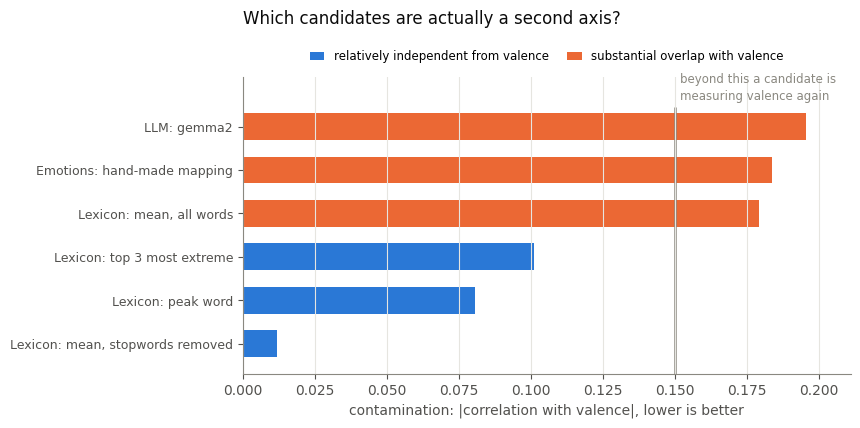

In [10]:
from matplotlib.patches import Patch

# ============================================================
# The Comparison as a Picture
# ============================================================

THRESHOLD = 0.15

plot = comparison.dropna(subset=["valence"]).copy()
plot["independence"] = plot["valence"].abs()

# barh draws position 0 at the bottom, so sorting ascending puts the most
# contaminated candidate on top and the usable ones below it
order = plot.sort_values("independence", ascending=True).index
positions = np.arange(len(order))
values = [plot.loc[label, "independence"] for label in order]
top = len(order) - 1

fig, ax = plt.subplots(figsize=(9.5, 4.8))
fig.subplots_adjust(left=0.34, right=0.98, top=0.78, bottom=0.16)

ax.barh(
    positions,
    values,
    color=[ORANGE if value > THRESHOLD else BLUE for value in values],
    height=0.62
)

ax.set_yticks(positions)
ax.set_yticklabels(order, fontsize=9)

# headroom above the top bar for the threshold label; the x-axis stays tight so no
# empty band opens up on the right
ax.set_ylim(-0.7, top + 1.15)
ax.set_xlim(0, max(values) * 1.08)

# the line stops below its own label instead of running through it
ax.vlines(THRESHOLD, -0.7, top + 0.45, color=INK_MUTED, lw=1.8, zorder=1)
ax.annotate(
    "beyond this a candidate is\nmeasuring valence again",
    xy=(THRESHOLD, top + 0.55),
    xytext=(4, 0),
    textcoords="offset points",
    ha="left",
    va="bottom",
    color=INK_MUTED,
    fontsize=8.5,
    linespacing=1.4
)

# legend above the plotting area, centred over it — there no bar can cover it, and
# the longest bar sits at the top
ax.legend(
    handles=[
        Patch(facecolor=BLUE, label="relatively independent from valence"),
        Patch(facecolor=ORANGE, label="substantial overlap with valence")
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncols=2,
    frameon=False,
    fontsize=8.5,
    handlelength=1.2,
    columnspacing=1.6
)

ax.grid(axis="y", visible=False)

ax.set_xlabel("contamination: |correlation with valence|, lower is better")

ax.set_title(
    "Which candidates are actually a second axis?",
    fontsize=12,
    loc="left",
    pad=38
)

plt.show()

### Both questions at once

The figure above answers one of the two questions a candidate has to pass. Independence
from valence is necessary, but it is not sufficient — a column of random numbers would
score perfectly on it and measure nothing at all.

The second question is whether the candidate measures activation in the first place, and
there are two referees for that: the published word list, which knows nothing about this
organisation, and the arousal criterion built from the survey in Step 1.

Putting each referee on its own horizontal axis and the contamination on the shared
vertical one shows both questions in a single view. **The lower right corner is the good
one.**

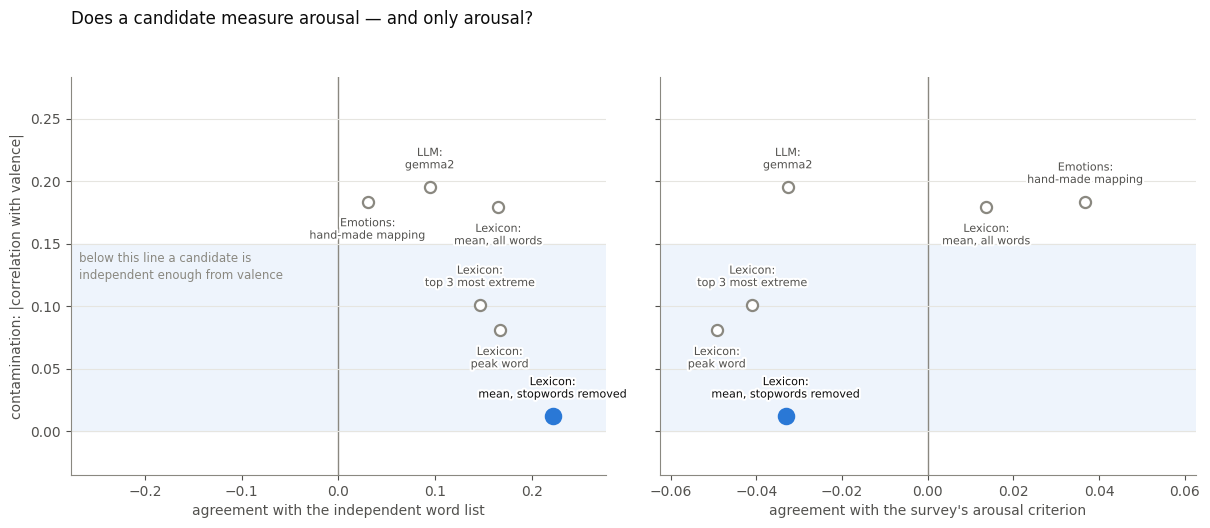

selected: Lexicon: mean, stopwords removed
The left panel has a spread to read; the right one does not — no candidate
agrees with the survey's own arousal criterion, in either direction.


In [11]:
import matplotlib.patheffects as pe

# ============================================================
# Validity and Independence Together
# ============================================================

field = comparison.dropna(subset=["valence"]).copy()
field["contamination"] = field["valence"].abs()

# the same rule Step 5 applies in prose: of the candidates that stay clear of valence,
# the one the independent list agrees with most
eligible = field[field["contamination"] <= THRESHOLD]
winner = eligible["BAWL-R"].idxmax() if len(eligible) else None

REFEREES = [
    ("BAWL-R", "agreement with the independent word list"),
    ("arousal criterion", "agreement with the survey's arousal criterion"),
]

ceiling = field["contamination"].max() * 1.45

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharey=True)
fig.subplots_adjust(left=0.08, right=0.98, top=0.84, bottom=0.13, wspace=0.10)

for ax, (column, caption) in zip(axes, REFEREES):
    reach = max(field[column].abs().max(), 0.05) * 1.25
    ax.axhspan(0, THRESHOLD, color="#eef4fc", zorder=0)
    ax.axvline(0, color=INK_MUTED, lw=1, zorder=1)

    # a label goes above its point unless a neighbour already claimed that space, in
    # which case it drops below — enough for six points, and it needs no layout engine
    taken = []
    for label, row in field.sort_values("contamination", ascending=False).iterrows():
        x, y = row[column], row["contamination"]
        above = not any(abs(x - other_x) < reach * 0.42 and
                        abs(y - other_y) < ceiling * 0.11
                        for other_x, other_y in taken)
        taken.append((x, y))

        is_winner = label == winner
        ax.plot(x, y, "o", ms=11 if is_winner else 8,
                color=BLUE if is_winner else "white",
                markeredgecolor=BLUE if is_winner else INK_MUTED,
                markeredgewidth=1.6, zorder=3)
        ax.annotate(
            label.replace(": ", ":\n"),
            xy=(x, y),
            xytext=(0, 12 if above else -12),
            textcoords="offset points",
            ha="center", va="bottom" if above else "top", fontsize=8,
            color=INK if is_winner else INK_SOFT, linespacing=1.3, zorder=4,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")],
        )

    ax.set_xlim(-reach, reach)
    ax.set_xlabel(caption)
    ax.grid(axis="x", visible=False)

axes[0].set_ylim(-0.035, ceiling)
axes[0].set_ylabel("contamination: |correlation with valence|")
axes[0].annotate("below this line a candidate is\nindependent enough from valence",
                 xy=(axes[0].get_xlim()[0], THRESHOLD), xytext=(6, -6),
                 textcoords="offset points", ha="left", va="top",
                 color=INK_MUTED, fontsize=8.5, linespacing=1.4)

fig.suptitle("Does a candidate measure arousal — and only arousal?",
             fontsize=12, x=0.08, ha="left", y=0.96, color=INK)

plt.show()

print(f"selected: {winner}")
print("The left panel has a spread to read; the right one does not — no candidate")
print("agrees with the survey's own arousal criterion, in either direction.")

The stopword-filtered lexicon mean shows the smallest relationship with valence while maintaining the strongest agreement with BAWL-R.

Although the overall signal remains weak, it provides the cleanest separation from the first circumplex dimension and is therefore retained as the preferred arousal candidate.

## Step 6 — Why the selected measure is still imperfect

The selected measure is the mean arousal score across content words. It shows the strongest agreement with the independent BAWL-R reference while remaining largely independent of valence.

At the same time, it is also the simplest approach in the comparison. It is based on individual word ratings and does not account for syntax, negation, or irony. For example, *"Das ist akzeptabel"* and *"Das ist nicht akzeptabel"* receive very similar scores.

This limitation helps explain the results above. The emotion model and the language model both produced measures that were more strongly related to valence, whereas the lexicon-based approach remained comparatively independent of the first circumplex dimension.

The final check below examines whether any independent activation signal can be recovered from the language-model score after removing its valence component.

In [12]:
# ============================================================
# Is Anything Left After Removing Valence?
# ============================================================

usable = comments[["arousal_llm", "valence", "referee_bawl",
                   "criterion_arousal"]].dropna()
if len(usable) > 50:
    # quadratic, because a U-shaped relation between the two axes is plausible
    fit = np.polyfit(usable["valence"], usable["arousal_llm"], 2)
    residual = usable["arousal_llm"] - np.polyval(fit, usable["valence"])

    print(f"{'':22s} {'raw':>8s} {'residual':>10s}")
    for label, other in [("~ valence", "valence"), ("~ BAWL-R", "referee_bawl"),
                         ("~ arousal criterion", "criterion_arousal")]:
        raw = usable["arousal_llm"].corr(usable[other], method="spearman")
        res = residual.corr(usable[other], method="spearman")
        print(f"{label:22s} {raw:+8.3f} {res:+10.3f}")
else:
    print("not enough scored comments for the residual check")

                            raw   residual
~ valence                -0.161     -0.004
~ BAWL-R                 +0.096     +0.030
~ arousal criterion      -0.043     -0.023


Removing the valence component largely eliminates the remaining signal. The residual score shows almost no association with valence, BAWL-R, or the arousal criterion.

This suggests that most of what the language model captured was already shared with valence. After removing that component, little evidence remains for an independent arousal signal.

## Step 7 — Hand over

In [13]:
# ============================================================
# Export
# ============================================================

WINNER = "Lexicon: mean, stopwords removed"

export = data.copy()
export["arousal_raw"] = comments[WINNER].reindex(export.index)
export["arousal"] = export["arousal_raw"].rank(pct=True) * 2 - 1
export["arousal_llm_rejected"] = comments["arousal_llm"].reindex(export.index)
export["criterion_arousal"] = comments["criterion_arousal"].reindex(export.index)

export.to_parquet(OUTPUT, index=False)
comparison.to_csv(WORK / f"{SOURCE}_arousal_comparison.csv", sep=";",
                  encoding="utf-8-sig", decimal=",")

print(f"winner: {WINNER}")
print(f"written: {OUTPUT.name}, {SOURCE}_arousal_comparison.csv")
print("\nThe rejected LLM measure travels along in the export as")
print("'arousal_llm_rejected'. Documented alternatives are retained for")
print("transparency and future comparison.")

winner: Lexicon: mean, stopwords removed
written: synthetic_arousal.parquet, synthetic_arousal_comparison.csv

The rejected LLM measure travels along in the export as
'arousal_llm_rejected'. Documented alternatives are retained for
transparency and future comparison.


## Key Findings

**Arousal can be measured, but only weakly.** None of the evaluated approaches produced a strong and unambiguous second circumplex dimension.

**The strongest candidate was a lexicon-based measure.** The mean arousal score across content words showed the strongest agreement with the independent BAWL-R reference while remaining largely independent of valence.

**But that agreement is between two word lists, not with the respondents.** BAWL-R and the IMS norms are built the same way: people rating single words out of context. Against the one criterion that comes from the respondents themselves — the rotated survey composite — no candidate shows any agreement at all, the winner included. Whether that is the measure failing or the criterion being too thin to detect anything cannot be decided from this data, which is precisely the limitation stated below.

**More sophisticated approaches did not improve the result.** Both the hand-made emotion mapping and the language-model approach showed stronger relationships with valence than with the arousal criterion.

**The central challenge was separation from valence.** Approaches that made greater use of semantic interpretation tended to capture pleasantness and unpleasantness more readily than activation.

**The main limitation is the validation criterion.** The survey contains only limited information about activation, making it difficult to establish a strong external reference for arousal. Additional survey items covering different regions of the circumplex would provide a more robust validation framework.

---

### Against the real data

| Metric | Synthetic | Real survey |
|----------|----------:|----------:|
| Winner | Lexicon: mean, stopwords removed | Lexicon: mean, stopwords removed |
| Winner ~ BAWL-R | +0.221 | +0.223 |
| Winner ~ valence | +0.012 | -0.058 |
| Emotion mapping ~ valence | +0.184 | +0.159 |
| LLM ~ valence | -0.196 | -0.661 |

**One thing to watch when reading this notebook's own numbers.** The synthetic
comments were generated with a target mood, and nothing in their generation was
calibrated towards arousal. Whatever the arousal figures do here, they do it
independently of how the data was built — which makes them a genuine test of the
method, unlike the valence figures in notebook 02.

**And one thing that may differ.** Synthetic comments express their mood more
plainly than real ones, which flatters methods that read for meaning. The LLM
candidate may therefore look better here than it does on real text. If it does, that
is the same effect notebook 02 describes, not a contradiction of the finding.